In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.layers import AveragePooling2D
from tensorflow.keras.layers import Dropout
from tensorflow.keras.layers import Flatten
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Input
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras import layers, models
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from tensorflow.keras.preprocessing.image import img_to_array
from tensorflow.keras.preprocessing.image import load_img
from tensorflow.keras.utils import to_categorical
from sklearn.preprocessing import LabelBinarizer
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from imutils import paths
import matplotlib.pyplot as plt
import numpy as np
import os

In [ ]:
dir1 = "/content/drive/MyDrive/nn project/Dataset/with_mask"
dir2 = "/content/drive/MyDrive/nn project/Dataset/without_mask"
dire = [dir1, dir2]

In [ ]:
# 1. Convert lists to NumPy arrays
data = np.array(data, dtype="float32")
labels = np.array(labels)

# 2. Perform one-hot encoding on the labels
lb = LabelBinarizer()
labels = lb.fit_transform(labels)
labels = to_categorical(labels)
# "with_mask" and "without_mask" now become [1, 0] and [0, 1]

# 3. Split the data into 80% training and 20% testing
(trainX, testX, trainY, testY) = train_test_split(
    data, labels,
    test_size=0.20,
    stratify=labels,
    random_state=42
)

# 4. Initialize the training data augmentation object
# This helps prevent overfitting by slightly altering images during training
aug = ImageDataGenerator(
    rotation_range=20,
    zoom_range=0.15,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.15,
    horizontal_flip=True,
    fill_mode="nearest"
)

In [ ]:
labels

array([[1., 0.],
       [1., 0.],
       [1., 0.],
       ...,
       [0., 1.],
       [0., 1.],
       [0., 1.]])

In [ ]:
# Extract the category names directly from the folder paths
categories = [os.path.basename(dir1), os.path.basename(dir2)]
# Expected output: ['with_mask', 'without_mask']

data = []
labels = [] # <-- New list to hold our ground truth

for directory in dire:
    # Get the label based on the current folder name
    category_label = os.path.basename(directory)

    for img in os.listdir(directory):
        img_path = os.path.join(directory, img)
        try:
            image = load_img(img_path, target_size=(224, 224))
            image = img_to_array(image)
            image = preprocess_input(image) # normalizaton

            # Save the processed image and its corresponding label
            data.append(image)
            labels.append(category_label) # <-- Append the label here

        except Exception as e:
            print(f"Error loading image {img_path}: {e}")

print(f"Successfully loaded {len(data)} images and {len(labels)} labels.")

Successfully loaded 5988 images and 5988 labels.


In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (Conv2D, MaxPooling2D, BatchNormalization,
                                      Flatten, Dense, Dropout)

In [ ]:
def build_cnn(input_shape=(224, 224, 3), num_classes=2):
    model = Sequential([

        # Block 1 – learn low-level edges/colors
        Conv2D(32, (3, 3), padding="same", activation="relu",
               input_shape=input_shape),
        BatchNormalization(),
        MaxPooling2D(pool_size=(2, 2)),          # → 112×112×32

        # Block 2 – learn shapes/textures
        Conv2D(64, (3, 3), padding="same", activation="relu"),
        BatchNormalization(),
        MaxPooling2D(pool_size=(2, 2)),          # → 56×56×64

        # Block 3 – learn higher-level features
        Conv2D(128, (3, 3), padding="same", activation="relu"),
        BatchNormalization(),
        MaxPooling2D(pool_size=(2, 2)),          # → 28×28×128

        # Block 4 – deeper feature abstraction
        Conv2D(128, (3, 3), padding="same", activation="relu"),
        BatchNormalization(),
        MaxPooling2D(pool_size=(2, 2)),          # → 14×14×128

        # Classifier head
        Flatten(),
        Dense(128, activation="relu"),
        Dropout(0.5),                            # prevent overfitting
        Dense(num_classes, activation="softmax")
    ])
    return model

model = build_cnn()
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_8 (Conv2D)               │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 28, 28, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_11          │ (None, 28, 28, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 2)              │           258 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,453,890 (13.18 MB)

 Trainable params: 3,453,186 (13.17 MB)

 Non-trainable params: 704 (2.75 KB)

In [ ]:
INIT_LR   = 1e-3
EPOCHS    = 20
BS        = 32

model.compile(
    optimizer=Adam(learning_rate=INIT_LR),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

In [ ]:
# ── Train (using the aug generator you already built) ─────────────────────────
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

callbacks = [
    EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True),
    ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=3, verbose=1)
]

H = model.fit(
    aug.flow(trainX, trainY, batch_size=BS),
    steps_per_epoch=len(trainX) // BS,
    validation_data=(testX, testY),
    epochs=EPOCHS,
    callbacks=callbacks
)

Epoch 1/20
149/149 ━━━━━━━━━━━━━━━━━━━━ 87s 495ms/step - accuracy: 0.9023 - loss: 0.6686 - val_accuracy: 0.8205 - val_loss: 0.6372 - learning_rate: 0.0010
Epoch 2/20
  1/149 ━━━━━━━━━━━━━━━━━━━━ 9s 62ms/step - accuracy: 1.0000 - loss: 0.1310

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


149/149 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 1.0000 - loss: 0.1310 - val_accuracy: 0.8164 - val_loss: 0.6275 - learning_rate: 0.0010
Epoch 3/20
149/149 ━━━━━━━━━━━━━━━━━━━━ 61s 412ms/step - accuracy: 0.9264 - loss: 0.2595 - val_accuracy: 0.8531 - val_loss: 0.5790 - learning_rate: 0.0010
Epoch 4/20
149/149 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9375 - loss: 0.3077 - val_accuracy: 0.8648 - val_loss: 0.5421 - learning_rate: 0.0010
Epoch 5/20
149/149 ━━━━━━━━━━━━━━━━━━━━ 64s 427ms/step - accuracy: 0.9384 - loss: 0.1964 - val_accuracy: 0.9023 - val_loss: 0.6100 - learning_rate: 0.0010
Epoch 6/20
149/149 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9688 - loss: 0.5413 - val_accuracy: 0.9048 - val_loss: 0.5539 - learning_rate: 0.0010
Epoch 7/20
149/149 ━━━━━━━━━━━━━━━━━━━━ 62s 416ms/step - accuracy: 0.9418 - loss: 0.1833 - val_accuracy: 0.9633 - val_loss: 0.1226 - learning_rate: 0.0010
Epoch 8/20
149/149 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9688 - loss: 0.0899 - va

38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 34ms/step
              precision    recall  f1-score   support

   with_mask       1.00      0.98      0.99       599
without_mask       0.98      1.00      0.99       599

    accuracy                           0.99      1198
   macro avg       0.99      0.99      0.99      1198
weighted avg       0.99      0.99      0.99      1198



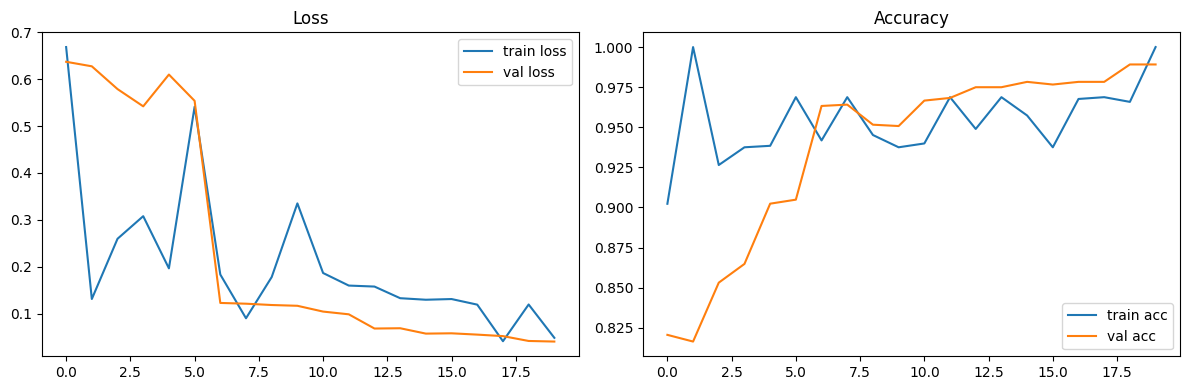

In [ ]:
# ── Evaluate & plot ───────────────────────────────────────────────────────────
print(classification_report(
    testY.argmax(axis=1),
    model.predict(testX).argmax(axis=1),
    target_names=lb.classes_
))

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(H.history["loss"],     label="train loss")
plt.plot(H.history["val_loss"], label="val loss")
plt.title("Loss"); plt.legend()

plt.subplot(1, 2, 2)
plt.plot(H.history["accuracy"],     label="train acc")
plt.plot(H.history["val_accuracy"], label="val acc")
plt.title("Accuracy"); plt.legend()

plt.tight_layout()
plt.show()

In [ ]:
model.save("C:/Users/Omar/OneDrive/Documents/Courses/Neural Networks/mask_detector.keras")
print("Model saved.")

Model saved.


In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

model2 = Sequential([
    # Block 1
    Conv2D(32, (3, 3), activation="relu", input_shape=(224, 224, 3)),
    MaxPooling2D(2, 2),

    # Block 2
    Conv2D(64, (3, 3), activation="relu"),
    MaxPooling2D(2, 2),

    # Block 3
    Conv2D(128, (3, 3), activation="relu"),
    MaxPooling2D(2, 2),

    # Classifier
    Flatten(),
    Dense(128, activation="relu"),
    Dropout(0.3),
    Dense(2, activation="softmax")
])

model2.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

model2.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_13 (Conv2D)              │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_13 (MaxPooling2D) │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_14 (MaxPooling2D) │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_15 (Conv2D)              │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_15 (MaxPooling2D) │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_4 (Flatten)             │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 2)              │           258 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,169,218 (42.61 MB)

 Trainable params: 11,169,218 (42.61 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
callbacks = [
    EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True),
    ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=3, verbose=1)
]

H = model2.fit(
    aug.flow(trainX, trainY, batch_size=BS),
    steps_per_epoch=len(trainX) // BS,
    validation_data=(testX, testY),
    epochs=EPOCHS,
    callbacks=callbacks
)

Epoch 1/20
149/149 ━━━━━━━━━━━━━━━━━━━━ 75s 470ms/step - accuracy: 0.9035 - loss: 0.2826 - val_accuracy: 0.9516 - val_loss: 0.1411 - learning_rate: 0.0010
Epoch 2/20
149/149 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9688 - loss: 0.0945 - val_accuracy: 0.9499 - val_loss: 0.1400 - learning_rate: 0.0010
Epoch 3/20
149/149 ━━━━━━━━━━━━━━━━━━━━ 62s 414ms/step - accuracy: 0.9468 - loss: 0.1581 - val_accuracy: 0.9524 - val_loss: 0.1214 - learning_rate: 0.0010
Epoch 4/20
149/149 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.9688 - loss: 0.1007 - val_accuracy: 0.9533 - val_loss: 0.1262 - learning_rate: 0.0010
Epoch 5/20
149/149 ━━━━━━━━━━━━━━━━━━━━ 63s 421ms/step - accuracy: 0.9454 - loss: 0.1611 - val_accuracy: 0.9524 - val_loss: 0.1351 - learning_rate: 0.0010
Epoch 6/20
  1/149 ━━━━━━━━━━━━━━━━━━━━ 7s 49ms/step - accuracy: 0.8750 - loss: 0.3512
Epoch 6: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
149/149 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8750 - loss: 

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step


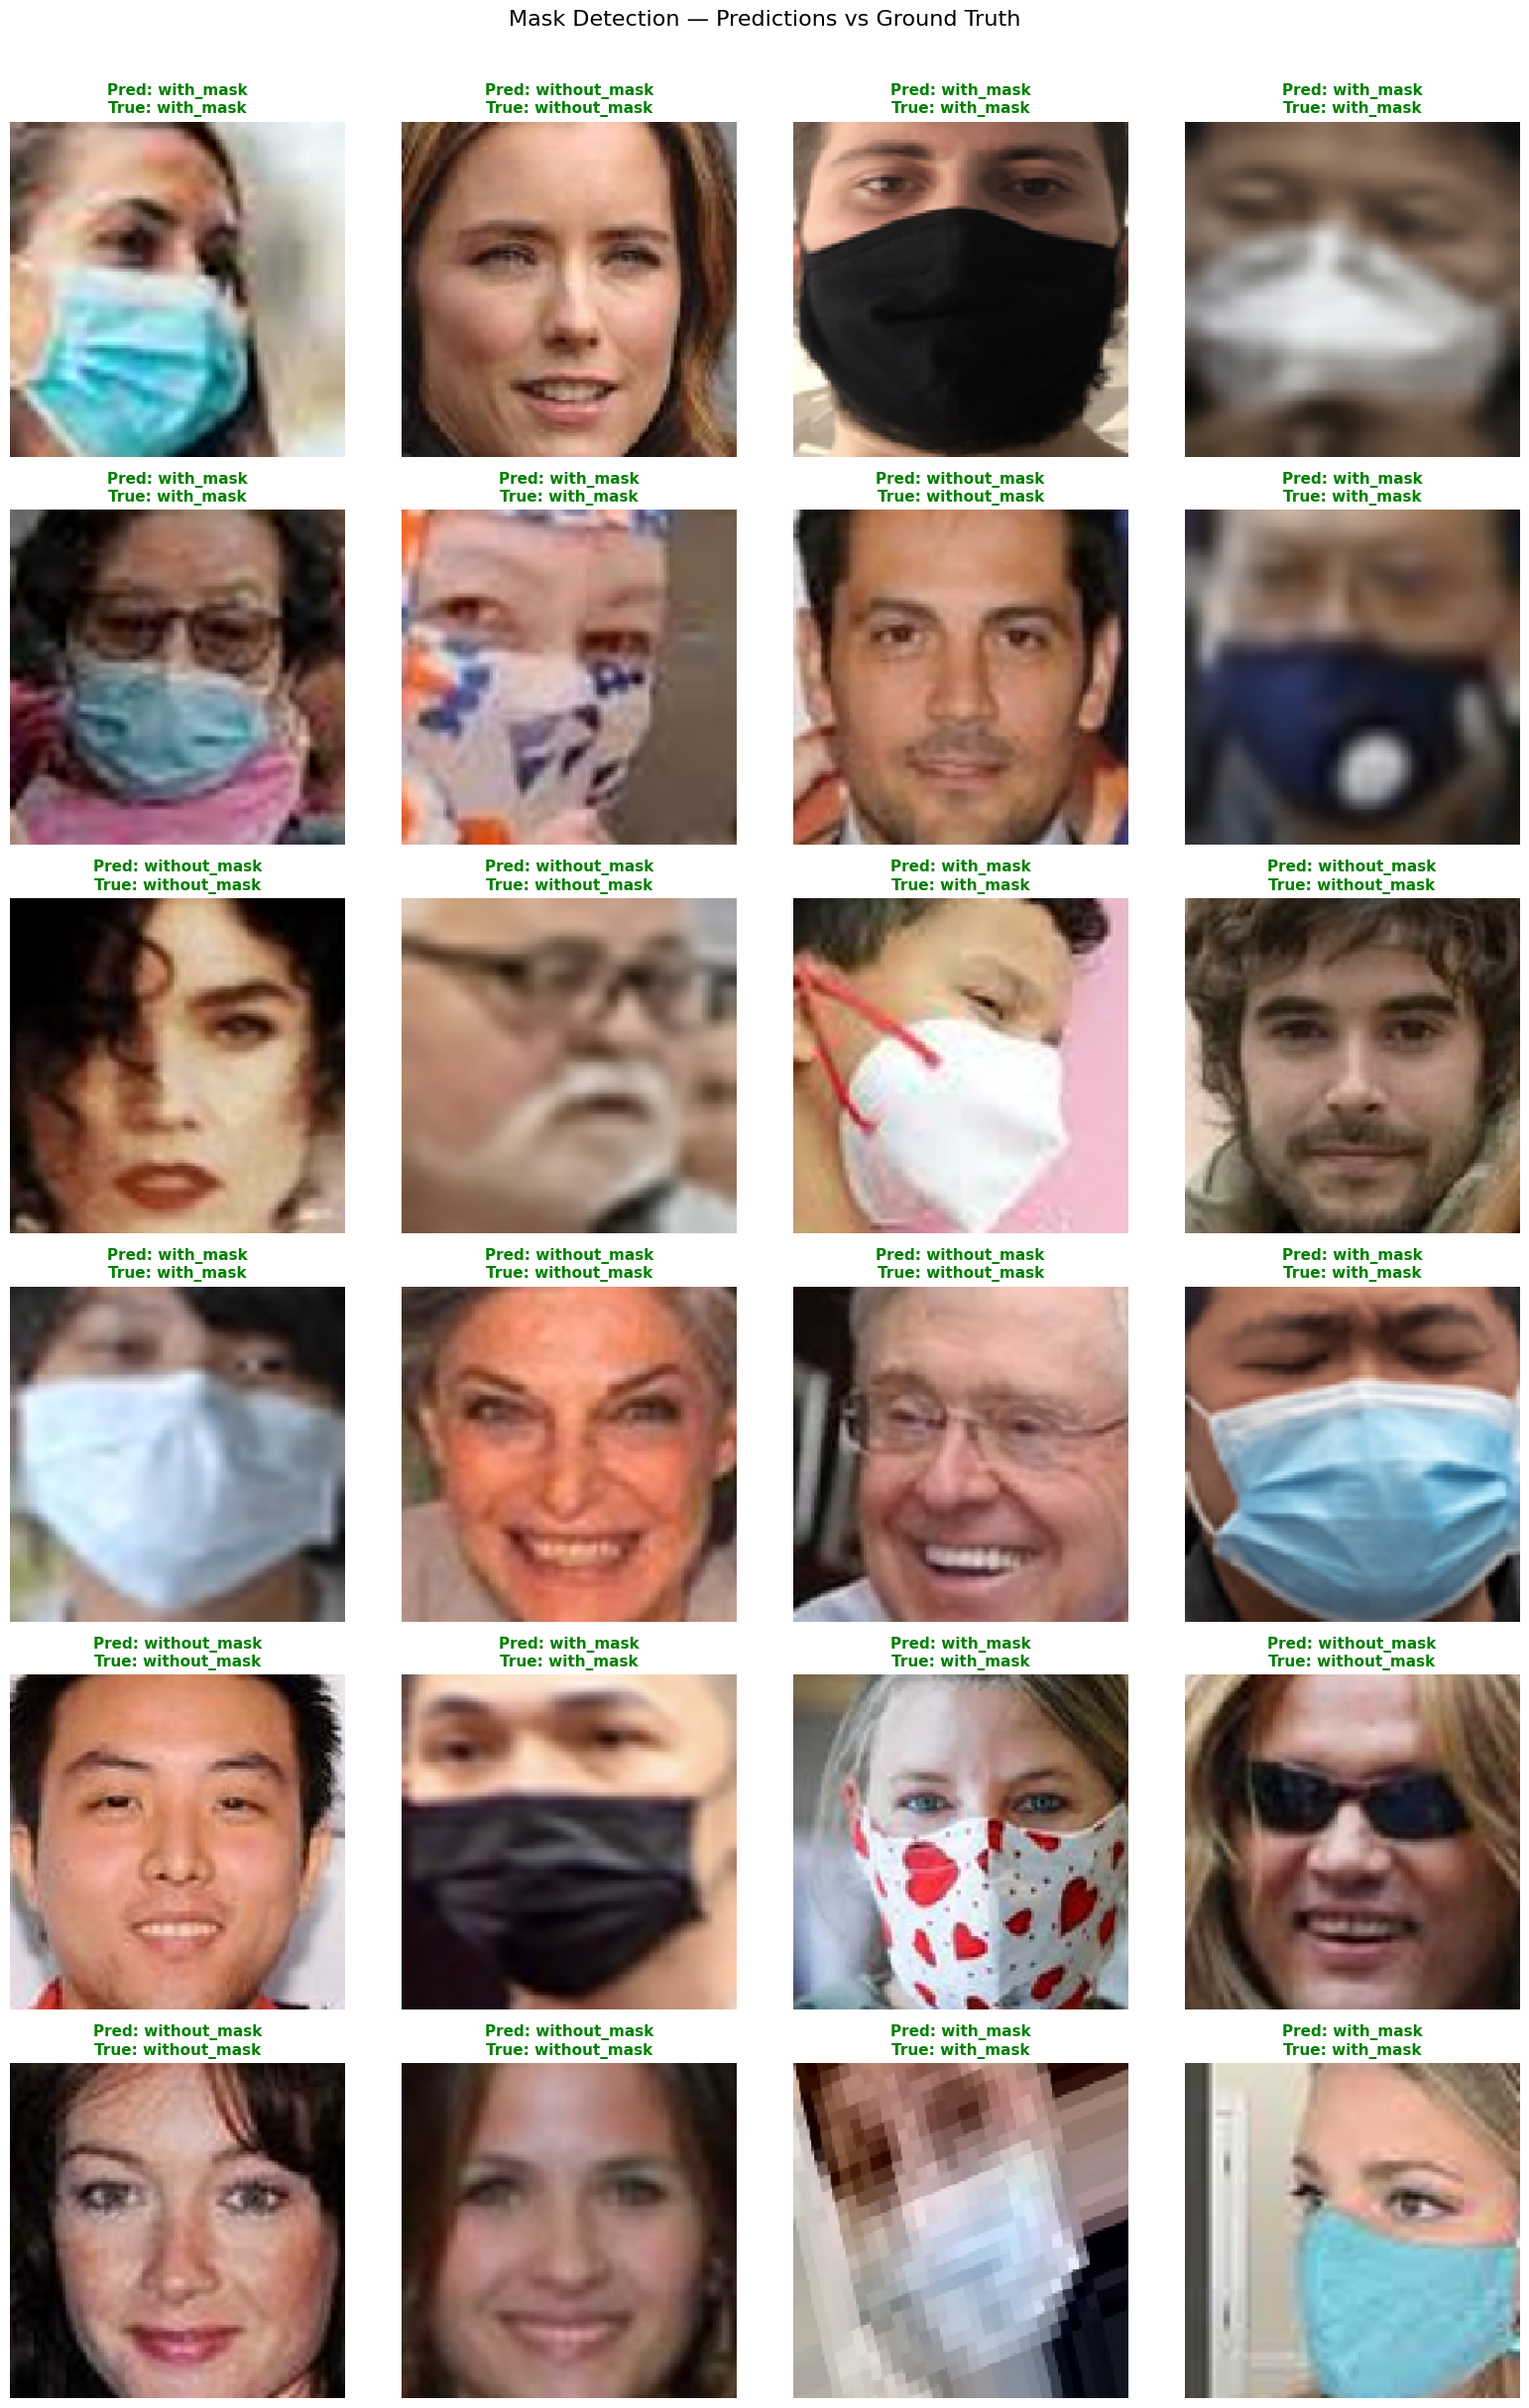

Correct: 25/25  (100.0%)


In [ ]:
# ── Visualize predictions on test data ───────────────────────────────────────
import matplotlib.pyplot as plt
import numpy as np

# Number of samples to display
NUM_SAMPLES = 25  # must be a perfect square (e.g. 9, 16, 25)

# Pick random indices from test set
indices = np.random.choice(len(testX), NUM_SAMPLES, replace=False)

# Get predictions
preds = model2.predict(testX[indices])
pred_labels = preds.argmax(axis=1)
true_labels = testY[indices].argmax(axis=1)

# Class names from LabelBinarizer
class_names = lb.classes_  # ['with_mask', 'without_mask']

# ── Plot ──────────────────────────────────────────────────────────────────────
cols = 4
rows = NUM_SAMPLES // cols

fig, axes = plt.subplots(rows, cols, figsize=(cols * 4, rows * 4))
fig.suptitle("Mask Detection — Predictions vs Ground Truth", fontsize=16, y=1.01)

for i, ax in enumerate(axes.flat):
    idx = indices[i]

    # Reverse MobileNetV2 preprocessing to get a displayable image
    # preprocess_input maps pixels to [-1, 1], so reverse it
    img_display = (testX[idx] + 1.0) / 2.0
    img_display = np.clip(img_display, 0, 1)

    pred_name = class_names[pred_labels[i]]
    true_name = class_names[true_labels[i]]
    correct    = pred_labels[i] == true_labels[i]

    ax.imshow(img_display)
    ax.axis("off")

    # Green title = correct, Red = wrong
    color = "green" if correct else "red"
    ax.set_title(
        f"Pred: {pred_name}\nTrue: {true_name}",
        fontsize=11,
        color=color,
        fontweight="bold"
    )

plt.tight_layout()
plt.show()

# ── Summary ───────────────────────────────────────────────────────────────────
correct_count = np.sum(pred_labels == true_labels)
print(f"Correct: {correct_count}/{NUM_SAMPLES}  "
      f"({correct_count/NUM_SAMPLES*100:.1f}%)")